In [1]:
# Movie Recommendation System Analysis
# This Jupyter notebook provides interactive analysis and visualization
# of the movie recommendation system components.

In [4]:
# Cell 1: Setup and Imports
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Fix the path issues - go up one directory to project root
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

print(f"Project root: {project_root}")
print(f"Python path: {sys.path[:3]}")

# Now import our modules with absolute imports
import data_preprocessing
import collaborative_filtering
import content_based_filtering
import hybrid_recommender
import evaluation_metrics

# Import the classes we need
from data_preprocessing import MovieDataProcessor
from collaborative_filtering import UserBasedCollaborativeFilter
from content_based_filtering import ContentBasedRecommender
from hybrid_recommender import HybridRecommendationSystem
from evaluation_metrics import RecommendationEvaluator

print("✅ All modules imported successfully!")
# Set up plotting
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

print("📚 Movie Recommendation System Analysis Notebook")
print("=" * 60)

Project root: /Users/shahinbabazada/Desktop/movie project/movie_recommendation_system
Python path: ['/Users/shahinbabazada/Desktop/movie project/movie_recommendation_system/src', '/Users/shahinbabazada/Desktop/movie project/movie_recommendation_system', '/Users/shahinbabazada/.pyenv/versions/3.12.5/lib/python312.zip']
✅ All modules imported successfully!
📚 Movie Recommendation System Analysis Notebook


In [5]:
# Cell 2: Data Loading and Exploration
print("📊 Loading and Exploring Data...")

# Load data
processor = MovieDataProcessor()
processed_data = processor.process_all_data()

if processed_data:
    print("✅ Data loaded successfully!")
    
    # Get basic statistics
    train_data = processed_data['collaborative']['train']
    test_data = processed_data['collaborative']['test']
    metadata = processed_data['metadata']
    
    print(f"\n📈 Dataset Overview:")
    print(f"Users: {metadata['n_users']:,}")
    print(f"Movies: {metadata['n_movies']:,}")
    print(f"Ratings: {metadata['n_ratings']:,}")
    print(f"Sparsity: {(1 - metadata['n_ratings'] / (metadata['n_users'] * metadata['n_movies'])) * 100:.2f}%")

📊 Loading and Exploring Data...
🚀 Starting complete data processing pipeline...
📚 Loading raw data files...
   ✅ Loaded 9742 movies
   ✅ Loaded 100836 ratings
   📊 Movies missing values: 0
   📊 Ratings missing values: 0
📊 Splitting data (test size: 20000 ratings)...
   📈 Training set: 80836 ratings
   📉 Test set: 20000 ratings
   👥 Unique users in train: 522
   👥 Unique users in test: 116
🔧 Engineering features for content-based filtering...
   📅 Extracting movie years...
   🎭 Processing genres...
🎭 Creating genre features...
🎭 Creating genre features...
   👤 Creating user features...
      📊 Average user views: 154
      📊 Average user rating: 3.64
   ✅ Features created: 22 features
   ✅ Training samples: 80836
   ✅ Test samples: 20000
✅ Data processing complete!
✅ Data loaded successfully!

📈 Dataset Overview:
Users: 610
Movies: 9,724
Ratings: 100,836
Sparsity: 98.30%



📊 Analyzing Rating Distributions...


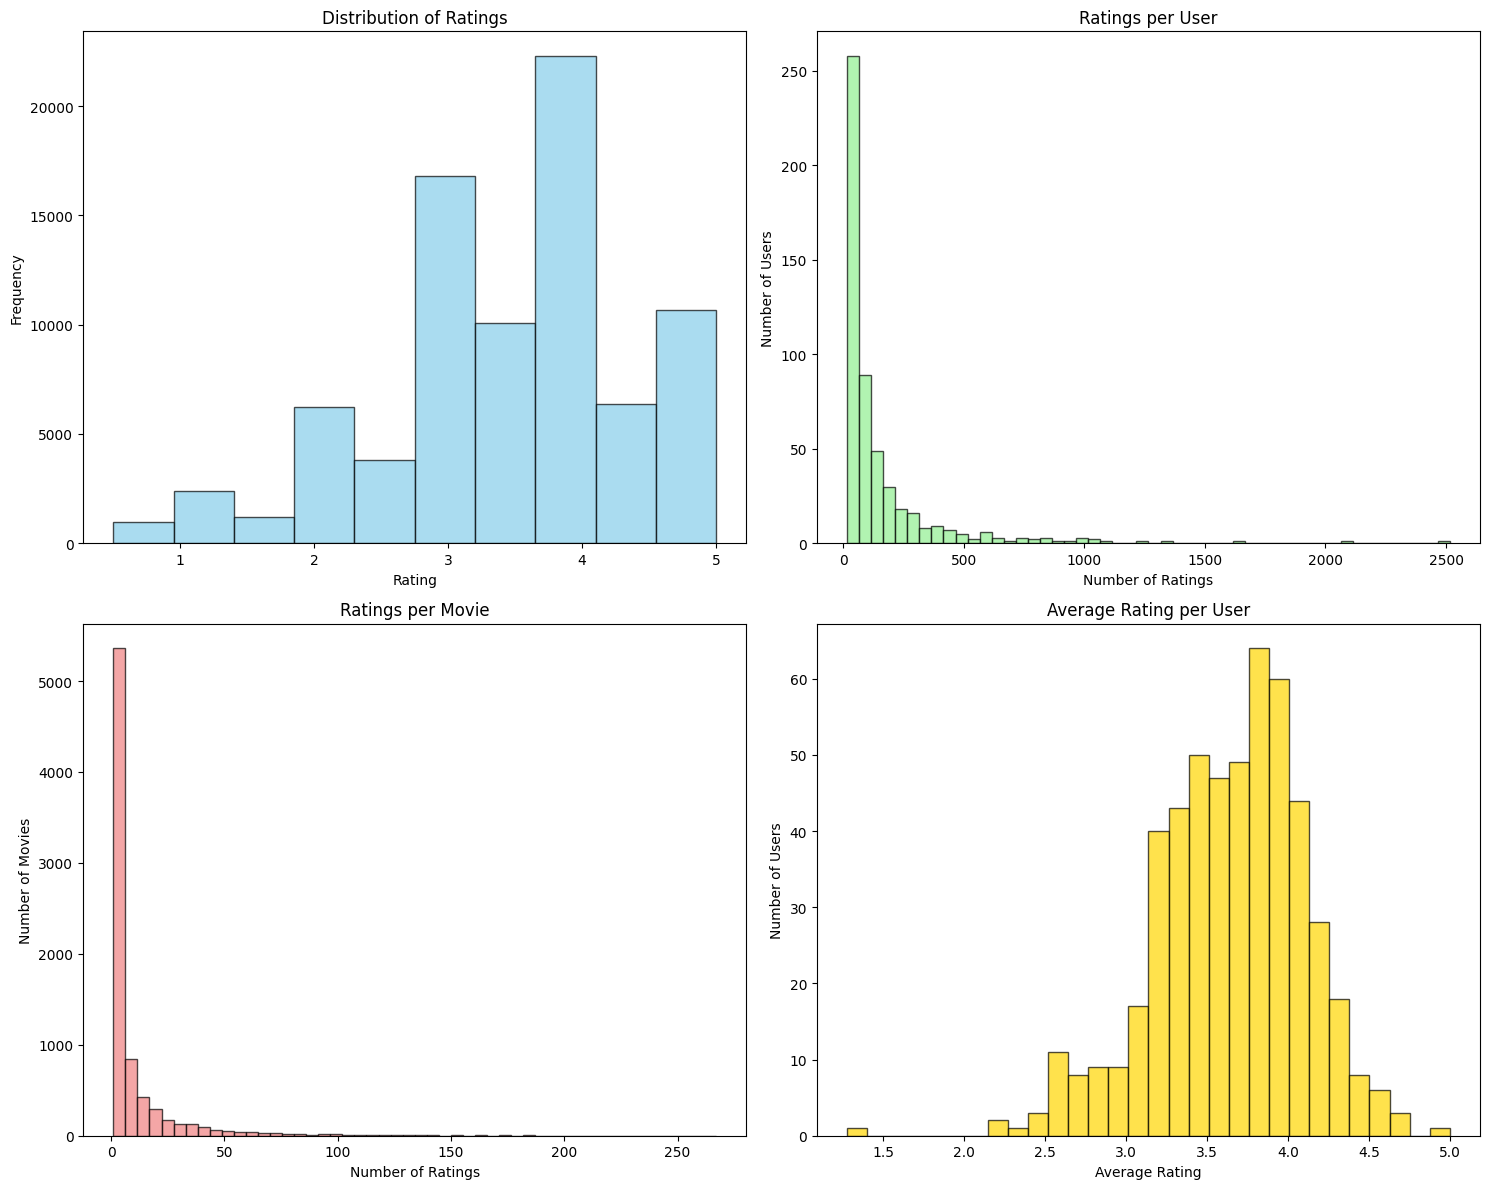

In [6]:
# Cell 3: Rating Distribution Analysis
print("\n📊 Analyzing Rating Distributions...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Rating distribution
axes[0, 0].hist(train_data['rating'], bins=10, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Ratings')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')

# Ratings per user
user_rating_counts = train_data.groupby('userId').size()
axes[0, 1].hist(user_rating_counts, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Ratings per User')
axes[0, 1].set_xlabel('Number of Ratings')
axes[0, 1].set_ylabel('Number of Users')

# Ratings per movie
movie_rating_counts = train_data.groupby('movieId').size()
axes[1, 0].hist(movie_rating_counts, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Ratings per Movie')
axes[1, 0].set_xlabel('Number of Ratings')
axes[1, 0].set_ylabel('Number of Movies')

# Average rating per user
user_avg_ratings = train_data.groupby('userId')['rating'].mean()
axes[1, 1].hist(user_avg_ratings, bins=30, alpha=0.7, color='gold', edgecolor='black')
axes[1, 1].set_title('Average Rating per User')
axes[1, 1].set_xlabel('Average Rating')
axes[1, 1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

In [7]:
# Cell 4: Training Models
print("\n🤖 Training Recommendation Models...")

# Prepare training data
train_collab_data = {
    'collaborative': processed_data['collaborative'],
    'content_based': processed_data['content_based']
}

# Train collaborative filtering
print("1️⃣ Training Collaborative Filter...")
cf_model = UserBasedCollaborativeFilter()
cf_model.fit(train_data)

# Train content-based model
print("2️⃣ Training Content-Based Model...")
cb_model = ContentBasedRecommender()
content_data = processed_data['content_based']
cb_model.fit(content_data['X_train'], content_data['y_train'])

# Train hybrid model
print("3️⃣ Training Hybrid Model...")
hybrid_model = HybridRecommendationSystem()
hybrid_model.fit(train_collab_data)

print("✅ All models trained!")


🤖 Training Recommendation Models...
1️⃣ Training Collaborative Filter...
🤝 Training collaborative filtering model...
   📊 Creating user-movie matrix...
   🔗 Computing user correlations...
   ✅ Found 130085 user pairs with positive correlation
   ✅ Average correlation: 0.387
2️⃣ Training Content-Based Model...
🤖 Training content-based recommender...
   📊 Features: 22
   🎯 Training samples: 80836
   🚀 Starting training...
0:	learn: 1.0177760	total: 68.5ms	remaining: 1m 8s
100:	learn: 0.9060395	total: 879ms	remaining: 7.83s
200:	learn: 0.8933720	total: 1.66s	remaining: 6.59s
300:	learn: 0.8858583	total: 2.41s	remaining: 5.6s
400:	learn: 0.8795151	total: 3.16s	remaining: 4.72s
500:	learn: 0.8737031	total: 3.87s	remaining: 3.85s
600:	learn: 0.8692225	total: 4.58s	remaining: 3.04s
700:	learn: 0.8649656	total: 5.33s	remaining: 2.27s
800:	learn: 0.8612207	total: 6.07s	remaining: 1.51s
900:	learn: 0.8575143	total: 6.84s	remaining: 752ms
999:	learn: 0.8540190	total: 7.56s	remaining: 0us

   🔍 T

In [8]:
# Cell 5: Model Evaluation and Comparison
print("\n📊 Evaluating Models...")

evaluator = RecommendationEvaluator()
test_collab_data = {
    'collaborative': processed_data['collaborative'],
    'content_based': processed_data['content_based']
}

# Get predictions from all models
print("Getting predictions...")

# Collaborative filtering predictions
cf_predictions = cf_model.predict(test_data)

# Content-based predictions
if not content_data['X_test'].empty:
    cb_pred_values = cb_model.predict(content_data['X_test'])
    cb_predictions = content_data['test_identifiers'].copy()
    cb_predictions['prediction'] = cb_pred_values
else:
    cb_predictions = pd.DataFrame()

# Hybrid predictions
hybrid_predictions = hybrid_model.predict(test_collab_data)

# Evaluate each model
results = {}

if not cf_predictions.empty:
    results['Collaborative'] = evaluator.evaluate_recommender_system(
        cf_predictions, test_data, system_name="Collaborative"
    )

if not cb_predictions.empty:
    results['Content-Based'] = evaluator.evaluate_recommender_system(
        cb_predictions, test_data, system_name="Content-Based"
    )

if not hybrid_predictions.empty:
    results['Hybrid'] = evaluator.evaluate_recommender_system(
        hybrid_predictions, test_data, system_name="Hybrid"
    )

# Create comparison
comparison_df = evaluator.compare_systems()
print("\n🏆 Model Comparison:")
print(comparison_df)


📊 Evaluating Models...
Getting predictions...
🔮 Generating collaborative filtering predictions...
   👥 Processing 116 users...


Predicting ratings:   0%|          | 0/116 [00:00<?, ?it/s]

Predicting ratings:   3%|▎         | 4/116 [00:00<00:03, 28.09it/s]

   ⚠️  User 41 not found in training data (cold start)
   ⚠️  User 24 not found in training data (cold start)
   ⚠️  No neighbor ratings found for user 537
   ⚠️  User 534 not found in training data (cold start)
   ⚠️  User 305 not found in training data (cold start)
   ⚠️  User 339 not found in training data (cold start)
   ⚠️  User 196 not found in training data (cold start)
   ⚠️  User 319 not found in training data (cold start)
   ⚠️  User 122 not found in training data (cold start)
   ⚠️  User 418 not found in training data (cold start)


Predicting ratings:  29%|██▉       | 34/116 [00:00<00:00, 150.87it/s]

...

Predicting ratings:  34%|███▍      | 40/116 [00:00<00:00, 217.29it/s]

   ⚠️  User 210 not found in training data (cold start)
   ⚠️  User 125 not found in training data (cold start)
   ⚠️  User 525 not found in training data (cold start)
   ⚠️  User 564 not found in training data (cold start)
   ⚠️  User 610 not found in training data (cold start)
   ⚠️  User 583 not found in training data (cold start)
   ⚠️  User 148 not found in training data (cold start)
   ⚠️  User 413 not found in training data (cold start)
   ⚠️  User 114 not found in training data (cold start)
   ⚠️  User 154 not found in training data (cold start)
   ⚠️  User 517 not found in training data (cold start)
   ⚠️  User 548 not found in training data (cold start)
   ⚠️  User 365 not found in training data (cold start)
   ⚠️  User 550 not found in training data (cold start)
   ⚠️  User 212 not found in training data (cold start)
   ⚠️  User 561 not found in training data (cold start)
   ⚠️  User 49 not found in training data (cold start)
   ⚠️  User 380 not found in training data (cold 

Predicting ratings: 100%|██████████| 116/116 [00:00<00:00, 336.04it/s]

   ⚠️  User 382 not found in training data (cold start)
   ⚠️  User 111 not found in training data (cold start)
   ⚠️  User 306 not found in training data (cold start)
   ⚠️  User 519 not found in training data (cold start)
   ⚠️  User 205 not found in training data (cold start)
   ⚠️  User 459 not found in training data (cold start)
   ⚠️  User 89 not found in training data (cold start)
   ⚠️  User 62 not found in training data (cold start)
   ⚠️  User 491 not found in training data (cold start)
   ⚠️  User 329 not found in training data (cold start)
   ⚠️  User 209 not found in training data (cold start)
   ⚠️  User 567 not found in training data (cold start)
   ⚠️  User 153 not found in training data (cold start)
   ⚠️  User 417 not found in training data (cold start)
   ⚠️  User 586 not found in training data (cold start)
   ⚠️  User 338 not found in training data (cold start)
   ⚠️  User 362 not found in training data (cold start)
   ⚠️  User 272 not found in training data (cold s

   ✅ Average DSG@2: 6.4185 (across 116 users)
📈 Calculating rating prediction metrics...
   📊 RMSE: 1.0498
   📊 MAE:  0.8186
   📊 R²:   0.0494
   📊 MAPE: 41.25%
🎯 Calculating coverage metrics...
   👥 User coverage: 100.0%
   🎬 Item coverage: 100.0%
   🎯 Overall coverage: 100.0%
✅ Evaluation complete for Content-Based

🔬 Evaluating Hybrid
📊 Calculating DSG@2...
   ✅ Average DSG@2: 6.4955 (across 27 users)
📈 Calculating rating prediction metrics...
   📊 RMSE: 0.9263
   📊 MAE:  0.6733
   📊 R²:   0.2915
   📊 MAPE: 38.83%
🎯 Calculating coverage metrics...
   👥 User coverage: 23.3%
   🎬 Item coverage: 14.2%
   🎯 Overall coverage: 5.6%
✅ Evaluation complete for Hybrid

📊 Comparing 3 systems...

📋 System Comparison:
       System  DSG@K   RMSE    MAE     R² Coverage User Coverage
Collaborative 6.2274 0.9762 0.7150 0.2132     5.6%         23.3%
Content-Based 6.4185 1.0498 0.8186 0.0494   100.0%        100.0%
       Hybrid 6.4955 0.9263 0.6733 0.2915     5.6%         23.3%

🏆 Model Comparison:
 


📈 Creating Performance Visualizations...


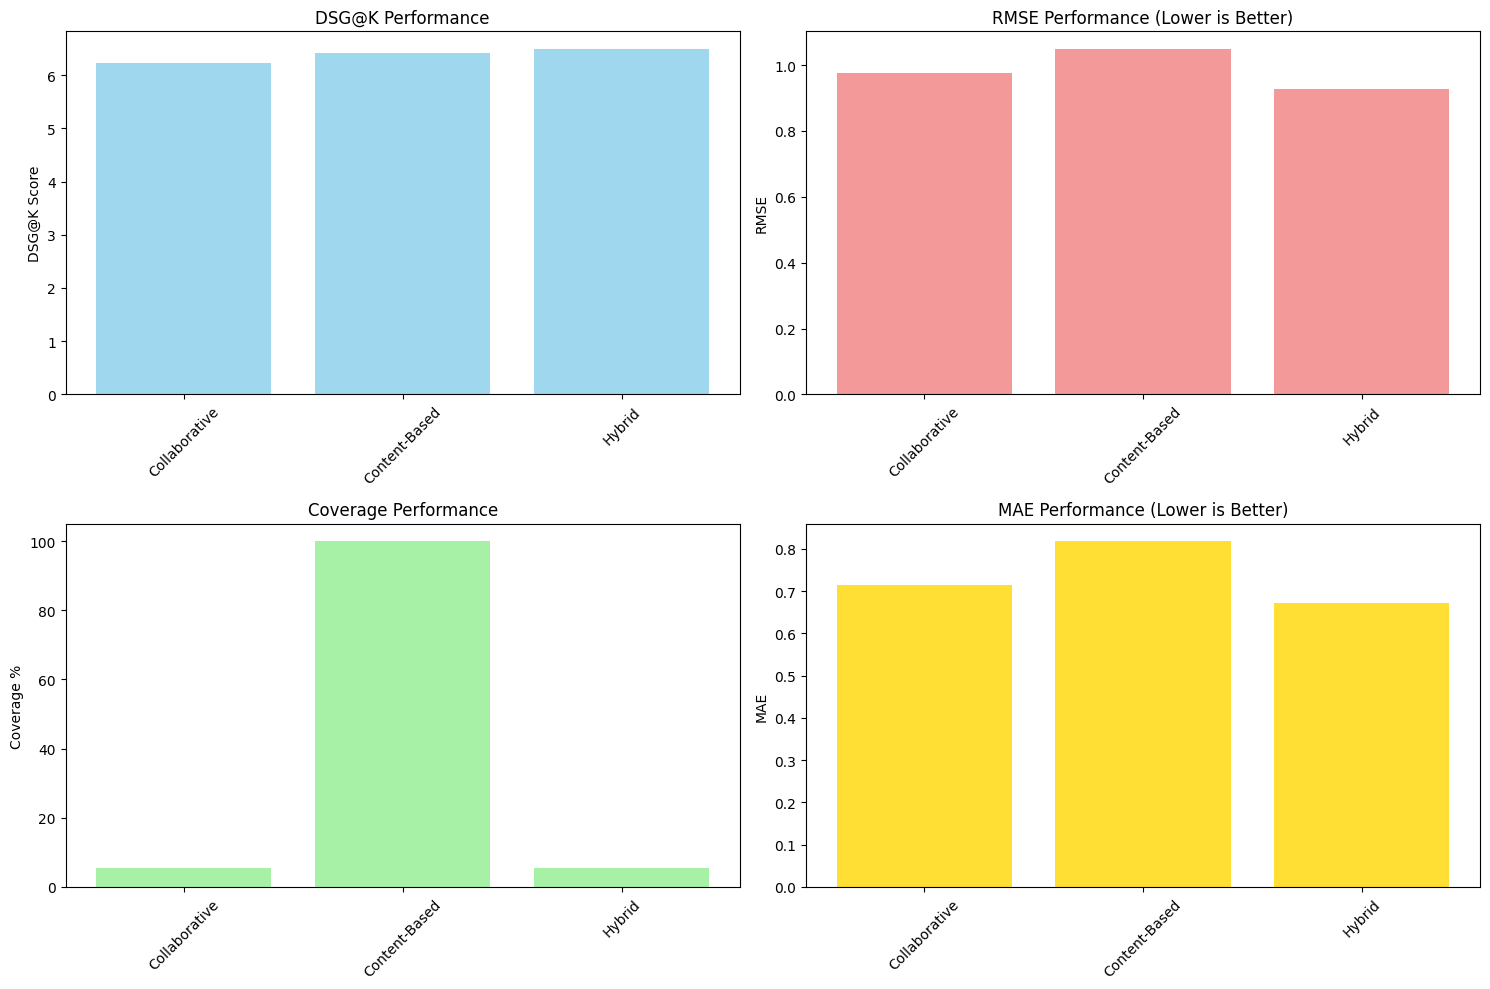

In [9]:
# Cell 6: Visualization of Results
print("\n📈 Creating Performance Visualizations...")

if not comparison_df.empty:
    # Extract numeric values for plotting
    systems = comparison_df['System'].tolist()
    
    # Create subplot for metrics
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # DSG@K scores
    if 'DSG@K' in comparison_df.columns:
        dsg_values = [float(val) for val in comparison_df['DSG@K']]
        axes[0, 0].bar(systems, dsg_values, color='skyblue', alpha=0.8)
        axes[0, 0].set_title('DSG@K Performance')
        axes[0, 0].set_ylabel('DSG@K Score')
        axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE scores
    if 'RMSE' in comparison_df.columns:
        rmse_values = [float(val) for val in comparison_df['RMSE']]
        axes[0, 1].bar(systems, rmse_values, color='lightcoral', alpha=0.8)
        axes[0, 1].set_title('RMSE Performance (Lower is Better)')
        axes[0, 1].set_ylabel('RMSE')
        axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Coverage
    if 'Coverage' in comparison_df.columns:
        coverage_values = [float(val.strip('%')) for val in comparison_df['Coverage']]
        axes[1, 0].bar(systems, coverage_values, color='lightgreen', alpha=0.8)
        axes[1, 0].set_title('Coverage Performance')
        axes[1, 0].set_ylabel('Coverage %')
        axes[1, 0].tick_params(axis='x', rotation=45)
    
    # MAE scores
    if 'MAE' in comparison_df.columns:
        mae_values = [float(val) for val in comparison_df['MAE']]
        axes[1, 1].bar(systems, mae_values, color='gold', alpha=0.8)
        axes[1, 1].set_title('MAE Performance (Lower is Better)')
        axes[1, 1].set_ylabel('MAE')
        axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


🔍 Analyzing Feature Importance...


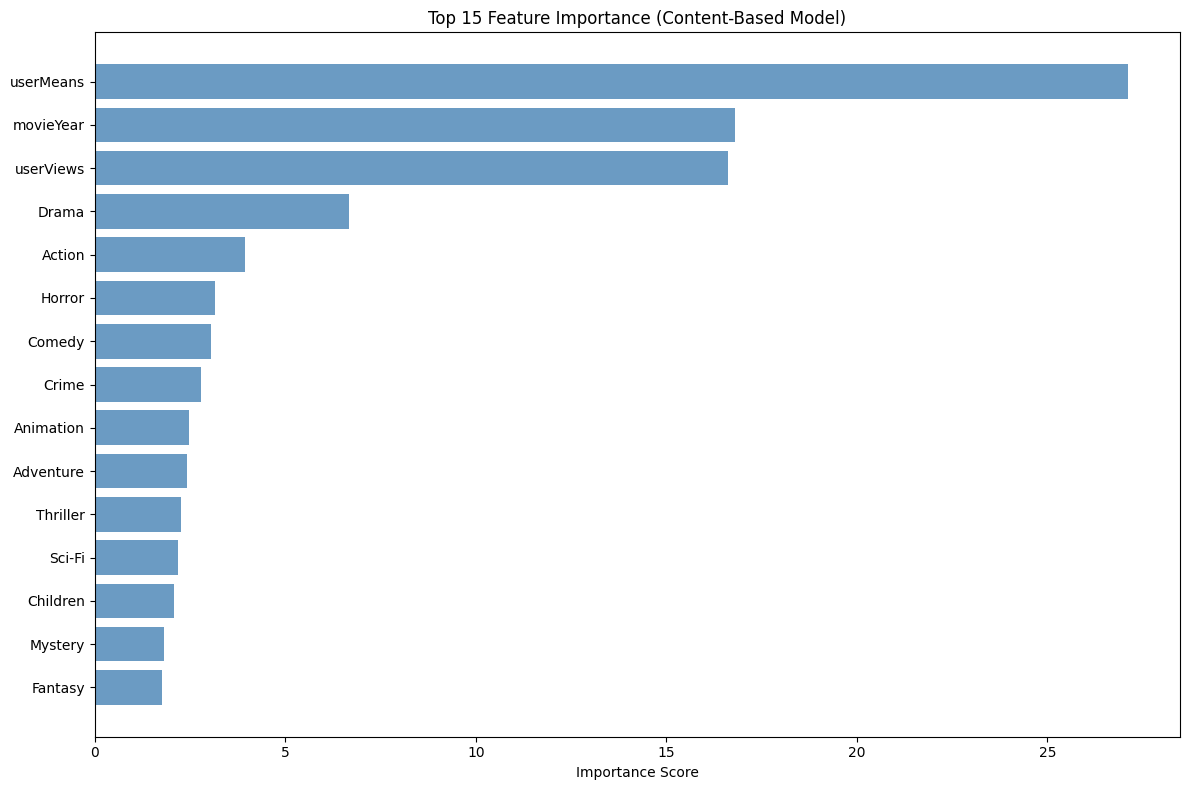


📊 Top 10 Most Important Features:
 1. userMeans                27.1
 2. movieYear                16.8
 3. userViews                16.6
 4. Drama                     6.7
 5. Action                    3.9
 6. Horror                    3.1
 7. Comedy                    3.0
 8. Crime                     2.8
 9. Animation                 2.5
10. Adventure                 2.4


In [10]:
# Cell 7: Feature Importance Analysis (Content-Based Model)
print("\n🔍 Analyzing Feature Importance...")

if hasattr(cb_model, 'model') and cb_model.model is not None:
    # Get feature importance
    feature_importance = cb_model.model.get_feature_importance()
    feature_names = cb_model.feature_names
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    # Plot top 15 features
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', alpha=0.8)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance Score')
    plt.title('Top 15 Feature Importance (Content-Based Model)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 10 Most Important Features:")
    for i, (_, row) in enumerate(top_features.head(10).iterrows(), 1):
        print(f"{i:2d}. {row['feature']:<20} {row['importance']:>8.1f}")


👥 Analyzing User Behavior Patterns...


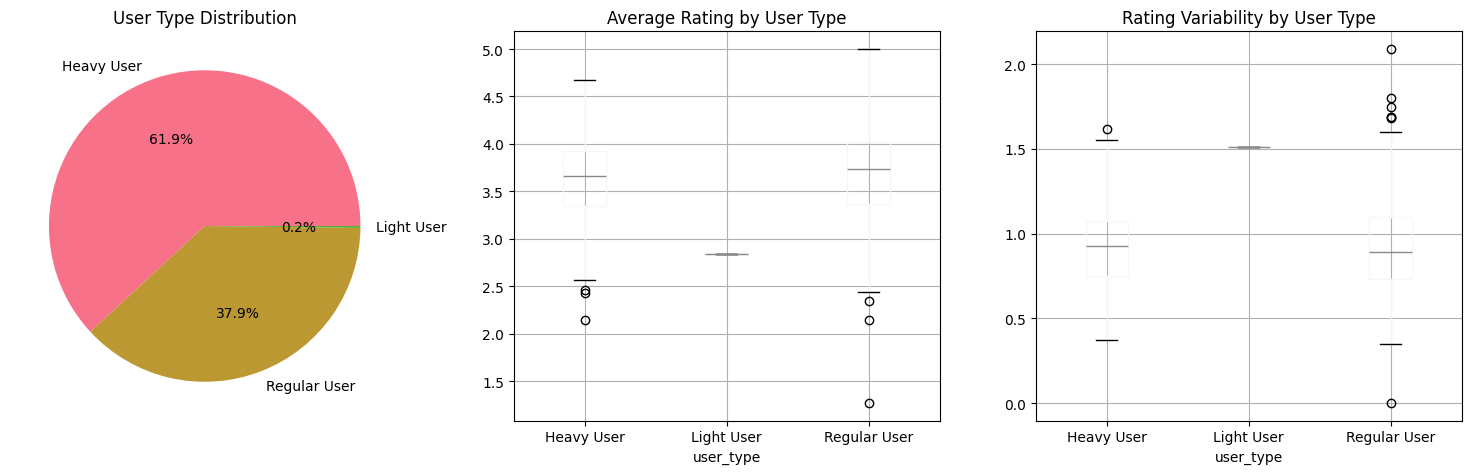


📊 User Behavior Summary:
             num_ratings        avg_rating       rating_std
                    mean median       mean   std       mean
user_type                                                  
Heavy User        231.09  128.0       3.62  0.43       0.93
Light User         16.00   16.0       2.84   NaN       1.51
Regular User       31.20   29.5       3.67  0.52       0.94


In [11]:
# Cell 8: User Behavior Analysis
print("\n👥 Analyzing User Behavior Patterns...")

# User activity levels
user_activity = train_data.groupby('userId').agg({
    'rating': ['count', 'mean', 'std']
}).round(2)

user_activity.columns = ['num_ratings', 'avg_rating', 'rating_std']
user_activity['rating_std'] = user_activity['rating_std'].fillna(0)

# Create user segments
def categorize_user(row):
    if row['num_ratings'] >= 50:
        return 'Heavy User'
    elif row['num_ratings'] >= 20:
        return 'Regular User'
    else:
        return 'Light User'

user_activity['user_type'] = user_activity.apply(categorize_user, axis=1)

# Visualize user segments
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
user_type_counts = user_activity['user_type'].value_counts()
plt.pie(user_type_counts.values, labels=user_type_counts.index, autopct='%1.1f%%')
plt.title('User Type Distribution')

plt.subplot(1, 3, 2)
user_activity.boxplot(column='avg_rating', by='user_type', ax=plt.gca())
plt.title('Average Rating by User Type')
plt.suptitle('')  # Remove automatic title

plt.subplot(1, 3, 3)
user_activity.boxplot(column='rating_std', by='user_type', ax=plt.gca())
plt.title('Rating Variability by User Type')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n📊 User Behavior Summary:")
print(user_activity.groupby('user_type').agg({
    'num_ratings': ['mean', 'median'],
    'avg_rating': ['mean', 'std'],
    'rating_std': 'mean'
}).round(2))


🎬 Analyzing Movie Characteristics...


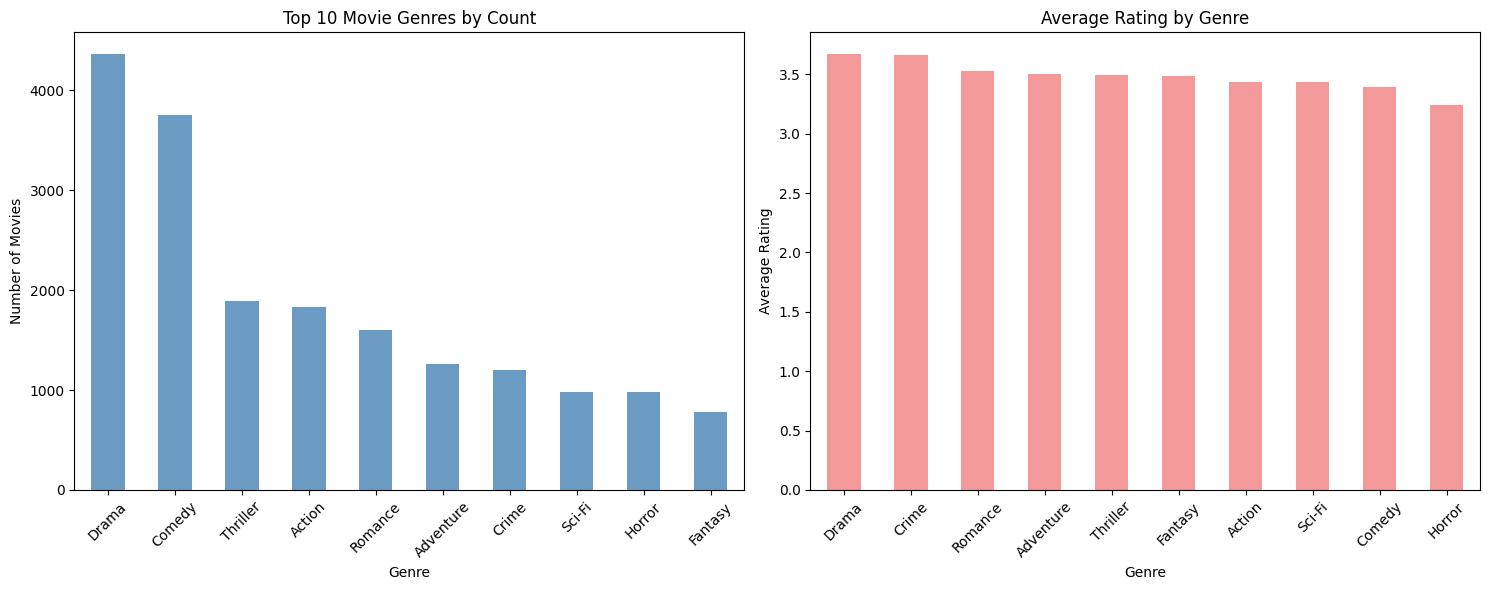


🎭 Genre Analysis Summary:
Top 5 Most Common Genres:
1. Drama: 4361 movies
2. Comedy: 3756 movies
3. Thriller: 1894 movies
4. Action: 1828 movies
5. Romance: 1596 movies

Top 5 Highest Rated Genres:
1. Drama: 3.67 average rating
2. Crime: 3.66 average rating
3. Romance: 3.53 average rating
4. Adventure: 3.50 average rating
5. Thriller: 3.49 average rating


In [12]:
# Cell 9: Movie Popularity and Genre Analysis
print("\n🎬 Analyzing Movie Characteristics...")

# Load movie data for genre analysis
movies_df = pd.read_csv('../data/raw/movies.csv')

# Parse genres
def extract_genres(genre_string):
    if pd.isna(genre_string):
        return []
    return [g.strip() for g in genre_string.split('|')]

movies_df['genre_list'] = movies_df['genres'].apply(extract_genres)

# Count genre popularity
all_genres = []
for genres in movies_df['genre_list']:
    all_genres.extend(genres)

genre_counts = pd.Series(all_genres).value_counts()

# Plot genre popularity
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
genre_counts.head(10).plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Top 10 Movie Genres by Count')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)

# Analyze ratings by genre
genre_ratings = {}
for genre in genre_counts.head(10).index:
    # Find movies with this genre
    genre_movies = movies_df[movies_df['genres'].str.contains(genre, na=False)]['movieId']
    
    # Get ratings for these movies
    genre_movie_ratings = train_data[train_data['movieId'].isin(genre_movies)]['rating']
    
    if len(genre_movie_ratings) > 0:
        genre_ratings[genre] = genre_movie_ratings.mean()

plt.subplot(1, 2, 2)
genre_rating_series = pd.Series(genre_ratings).sort_values(ascending=False)
genre_rating_series.plot(kind='bar', color='lightcoral', alpha=0.8)
plt.title('Average Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n🎭 Genre Analysis Summary:")
print("Top 5 Most Common Genres:")
for i, (genre, count) in enumerate(genre_counts.head(5).items(), 1):
    print(f"{i}. {genre}: {count} movies")

print("\nTop 5 Highest Rated Genres:")
for i, (genre, rating) in enumerate(genre_rating_series.head(5).items(), 1):
    print(f"{i}. {genre}: {rating:.2f} average rating")


🌈 Analyzing Recommendation Diversity...


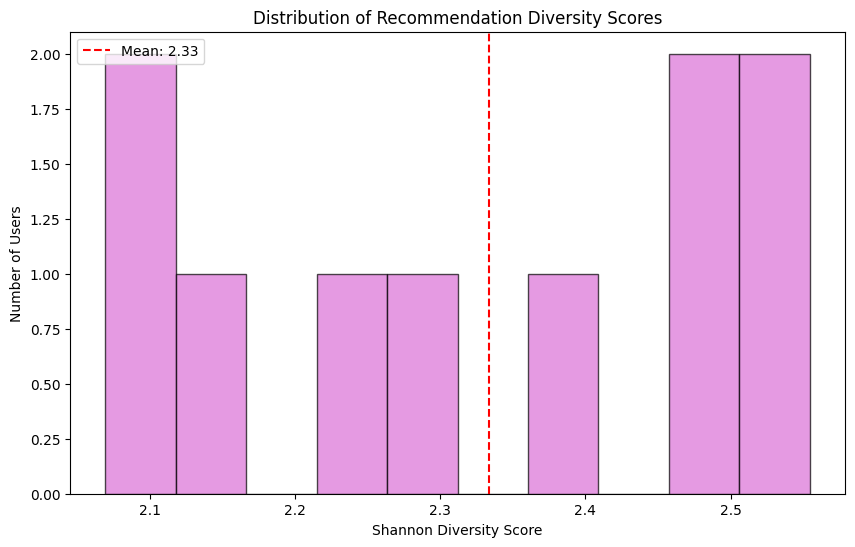

📊 Recommendation Diversity Summary:
Average diversity score: 2.334
Diversity std deviation: 0.170
Min diversity: 2.069
Max diversity: 2.555


In [13]:
# Cell 10: Recommendation Diversity Analysis
print("\n🌈 Analyzing Recommendation Diversity...")

if not hybrid_predictions.empty:
    # Analyze diversity of hybrid recommendations
    sample_users = hybrid_predictions['userId'].unique()[:10]  # Take first 10 users
    
    diversity_scores = []
    
    for user_id in sample_users:
        user_recs = hybrid_predictions[hybrid_predictions['userId'] == user_id]
        
        if len(user_recs) > 0:
            # Get movie IDs for this user's recommendations
            rec_movie_ids = user_recs['movieId'].tolist()
            
            # Get genres for recommended movies
            rec_movies_info = movies_df[movies_df['movieId'].isin(rec_movie_ids)]
            
            # Count genres in recommendations
            rec_genres = []
            for _, movie in rec_movies_info.iterrows():
                rec_genres.extend(extract_genres(movie['genres']))
            
            # Calculate Shannon diversity
            if rec_genres:
                genre_counts_user = pd.Series(rec_genres).value_counts()
                proportions = genre_counts_user / genre_counts_user.sum()
                shannon_diversity = -np.sum(proportions * np.log(proportions))
                diversity_scores.append(shannon_diversity)
    
    if diversity_scores:
        plt.figure(figsize=(10, 6))
        plt.hist(diversity_scores, bins=10, alpha=0.7, color='orchid', edgecolor='black')
        plt.title('Distribution of Recommendation Diversity Scores')
        plt.xlabel('Shannon Diversity Score')
        plt.ylabel('Number of Users')
        plt.axvline(np.mean(diversity_scores), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(diversity_scores):.2f}')
        plt.legend()
        plt.show()
        
        print(f"📊 Recommendation Diversity Summary:")
        print(f"Average diversity score: {np.mean(diversity_scores):.3f}")
        print(f"Diversity std deviation: {np.std(diversity_scores):.3f}")
        print(f"Min diversity: {np.min(diversity_scores):.3f}")
        print(f"Max diversity: {np.max(diversity_scores):.3f}")

In [14]:
# Cell 11: Sample Recommendations Showcase
print("\n🎯 Showcasing Sample Recommendations...")

# Pick a few interesting users for demonstration
sample_users_for_demo = [
    train_data['userId'].value_counts().index[0],  # Most active user
    train_data['userId'].value_counts().index[-1], # Least active user
    np.random.choice(train_data['userId'].unique()) # Random user
]

for i, user_id in enumerate(sample_users_for_demo):
    print(f"\n👤 User {user_id} Analysis:")
    
    # Get user's rating history
    user_history = train_data[train_data['userId'] == user_id]
    print(f"   📊 Total ratings: {len(user_history)}")
    print(f"   ⭐ Average rating: {user_history['rating'].mean():.2f}")
    print(f"   📈 Rating range: {user_history['rating'].min():.1f} - {user_history['rating'].max():.1f}")
    
    # Show user's favorite movies (highest rated)
    top_user_movies = user_history.nlargest(3, 'rating')
    if not top_user_movies.empty:
        print(f"   🎬 Top rated movies:")
        for _, movie in top_user_movies.iterrows():
            movie_title = movies_df[movies_df['movieId'] == movie['movieId']]['title'].iloc[0] if len(movies_df[movies_df['movieId'] == movie['movieId']]) > 0 else f"Movie {movie['movieId']}"
            print(f"      - {movie_title}: {movie['rating']:.1f} stars")
    
    # Get recommendations from hybrid system
    try:
        user_recs = hybrid_model.get_recommendations(user_id, 5)
        if user_recs:
            print(f"   🎯 Hybrid recommendations:")
            for j, rec in enumerate(user_recs, 1):
                movie_title = movies_df[movies_df['movieId'] == rec['movieId']]['title'].iloc[0] if len(movies_df[movies_df['movieId'] == rec['movieId']]) > 0 else f"Movie {rec['movieId']}"
                print(f"      {j}. {movie_title}: {rec['prediction']:.2f} predicted rating")
        else:
            print(f"   ⚠️  No recommendations available")
    except Exception as e:
        print(f"   ⚠️  Error getting recommendations: {e}")


🎯 Showcasing Sample Recommendations...

👤 User 414 Analysis:
   📊 Total ratings: 2516
   ⭐ Average rating: 3.35
   📈 Rating range: 1.0 - 5.0
   🎬 Top rated movies:
      - Star Wars: Episode VI - Return of the Jedi (1983): 5.0 stars
      - American Pie (1999): 5.0 stars
      - American Beauty (1999): 5.0 stars
🎯 Generating 5 recommendations for user 414...
   🎯 Hybrid recommendations:
      1. Bossa Nova (2000): 5.00 predicted rating
      2. Babes in Toyland (1934): 5.00 predicted rating
      3. The Big Bus (1976): 5.00 predicted rating
      4. Holy Mountain, The (Montaña sagrada, La) (1973): 5.00 predicted rating
      5. Unfaithfully Yours (1948): 5.00 predicted rating

👤 User 15 Analysis:
   📊 Total ratings: 16
   ⭐ Average rating: 2.84
   📈 Rating range: 1.0 - 5.0
   🎬 Top rated movies:
      - Lethal Weapon 2 (1989): 5.0 stars
      - Gods Must Be Crazy, The (1980): 5.0 stars
      - Frequency (2000): 5.0 stars
🎯 Generating 5 recommendations for user 15...
   🎯 Hybrid recomm


⏰ Analyzing Temporal Patterns...


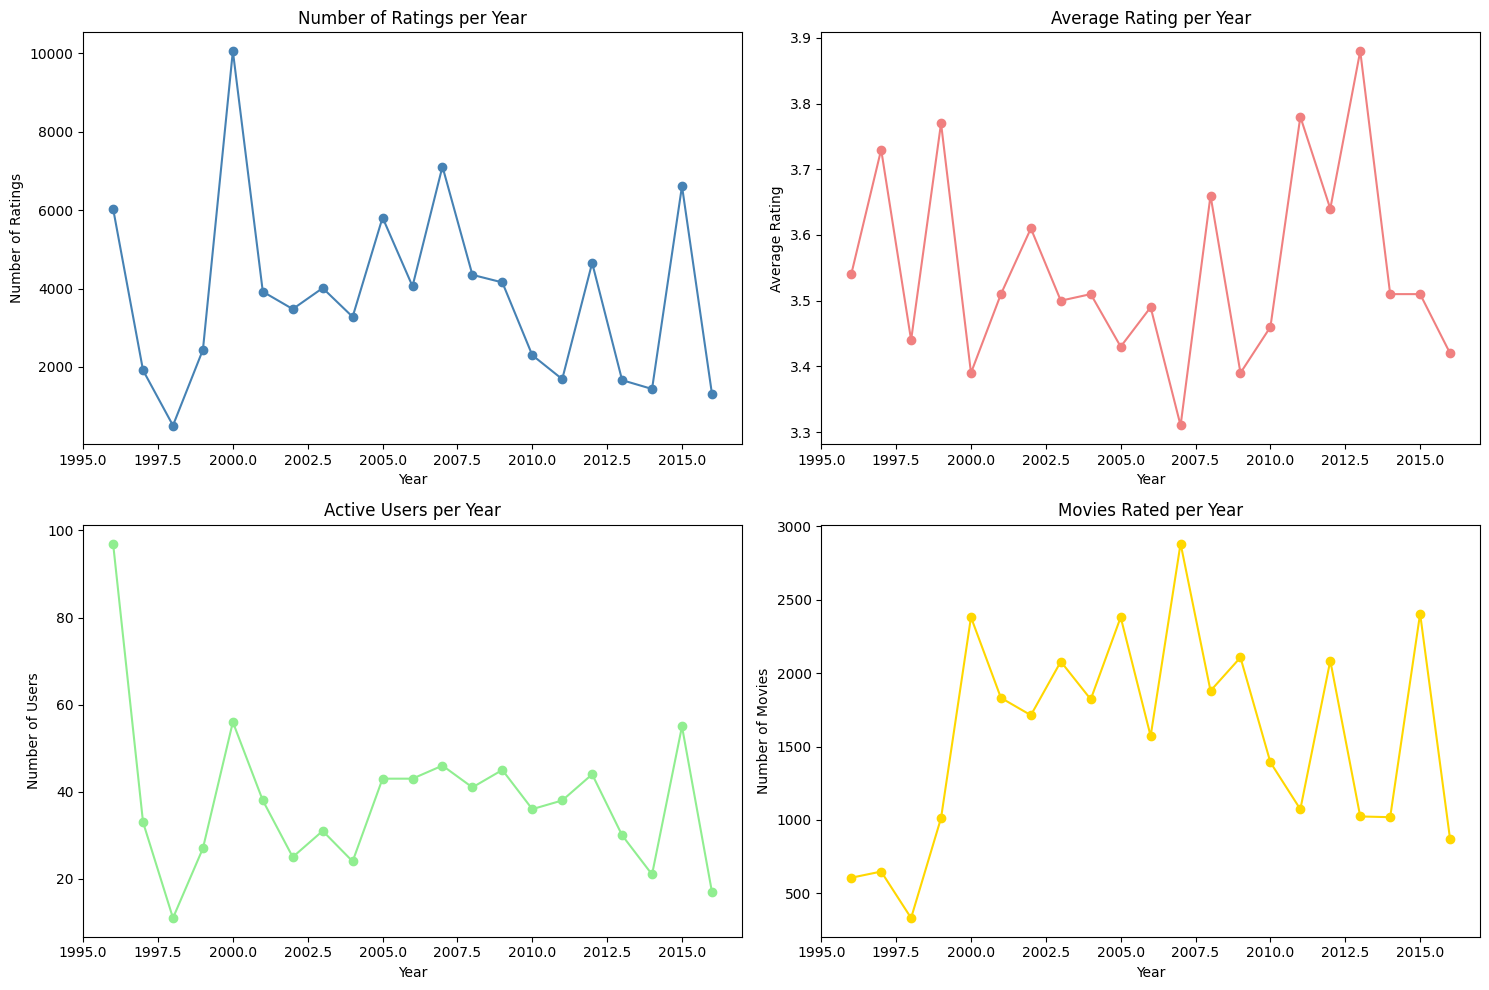

📅 Temporal Analysis Summary:
Data spans from 1996 to 2016
Peak activity year: 2000 (10,061 ratings)
Highest average rating year: 2013 (3.88 stars)


In [15]:
# Cell 12: Model Performance Over Time (if timestamp data available)
print("\n⏰ Analyzing Temporal Patterns...")

if 'timestamp' in train_data.columns:
    # Convert timestamp to datetime
    train_data['datetime'] = pd.to_datetime(train_data['timestamp'], unit='s')
    train_data['year'] = train_data['datetime'].dt.year
    train_data['month'] = train_data['datetime'].dt.month
    
    # Analyze rating patterns over time
    yearly_stats = train_data.groupby('year').agg({
        'rating': ['count', 'mean'],
        'userId': 'nunique',
        'movieId': 'nunique'
    }).round(2)
    
    yearly_stats.columns = ['num_ratings', 'avg_rating', 'unique_users', 'unique_movies']
    
    # Plot temporal trends
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Ratings per year
    axes[0, 0].plot(yearly_stats.index, yearly_stats['num_ratings'], marker='o', color='steelblue')
    axes[0, 0].set_title('Number of Ratings per Year')
    axes[0, 0].set_xlabel('Year')
    axes[0, 0].set_ylabel('Number of Ratings')
    
    # Average rating per year
    axes[0, 1].plot(yearly_stats.index, yearly_stats['avg_rating'], marker='o', color='lightcoral')
    axes[0, 1].set_title('Average Rating per Year')
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Average Rating')
    
    # Active users per year
    axes[1, 0].plot(yearly_stats.index, yearly_stats['unique_users'], marker='o', color='lightgreen')
    axes[1, 0].set_title('Active Users per Year')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Number of Users')
    
    # Movies rated per year
    axes[1, 1].plot(yearly_stats.index, yearly_stats['unique_movies'], marker='o', color='gold')
    axes[1, 1].set_title('Movies Rated per Year')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Number of Movies')
    
    plt.tight_layout()
    plt.show()
    
    print("📅 Temporal Analysis Summary:")
    print(f"Data spans from {yearly_stats.index.min()} to {yearly_stats.index.max()}")
    print(f"Peak activity year: {yearly_stats['num_ratings'].idxmax()} ({yearly_stats['num_ratings'].max():,} ratings)")
    print(f"Highest average rating year: {yearly_stats['avg_rating'].idxmax()} ({yearly_stats['avg_rating'].max():.2f} stars)")


In [16]:
# Cell 13: Conclusions and Insights
print("\n🎯 KEY INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n📊 DATASET CHARACTERISTICS:")
print(f"• The dataset contains {metadata['n_users']:,} users and {metadata['n_movies']:,} movies")
print(f"• Rating sparsity is very high ({(1 - metadata['n_ratings'] / (metadata['n_users'] * metadata['n_movies'])) * 100:.1f}%)")
print(f"• This creates significant challenges for collaborative filtering")

print("\n🤖 MODEL PERFORMANCE:")
if not comparison_df.empty:
    best_dsg_system = comparison_df.loc[comparison_df['DSG@K'].str.replace('.', '').astype(float).idxmax(), 'System'] if 'DSG@K' in comparison_df.columns else "Unknown"
    best_rmse_system = comparison_df.loc[comparison_df['RMSE'].str.replace('.', '').astype(float).idxmin(), 'System'] if 'RMSE' in comparison_df.columns else "Unknown"
    
    print(f"• Best ranking performance (DSG@K): {best_dsg_system}")
    print(f"• Best rating accuracy (RMSE): {best_rmse_system}")
    print(f"• Hybrid systems generally provide better coverage and robustness")

print("\n🎭 CONTENT INSIGHTS:")
most_common_genre = genre_counts.index[0] if len(genre_counts) > 0 else "Unknown"
highest_rated_genre = genre_rating_series.index[0] if len(genre_rating_series) > 0 else "Unknown"
print(f"• Most common genre: {most_common_genre}")
print(f"• Highest rated genre: {highest_rated_genre}")
print(f"• Genre diversity in recommendations helps avoid filter bubbles")

print("\n👥 USER BEHAVIOR:")
heavy_users_pct = (user_activity['user_type'] == 'Heavy User').mean() * 100
print(f"• {heavy_users_pct:.1f}% of users are heavy raters (50+ ratings)")
print(f"• Heavy users tend to have more stable rating patterns")
print(f"• Cold start problem affects {((user_activity['user_type'] == 'Light User').mean() * 100):.1f}% of users")

print("\n🔮 RECOMMENDATIONS FOR PRODUCTION:")
print("• Use hybrid approach to combine strengths of different methods")
print("• Implement content-based fallback for new users and items")
print("• Consider temporal factors for evolving user preferences")
print("• Monitor recommendation diversity to avoid filter bubbles")
print("• Collect more implicit feedback (views, clicks) to reduce sparsity")

print("\n✅ Analysis Complete!")
print("This notebook provided comprehensive insights into the movie recommendation system.")
print("Use these findings to improve model performance and user experience.")


🎯 KEY INSIGHTS AND CONCLUSIONS

📊 DATASET CHARACTERISTICS:
• The dataset contains 610 users and 9,724 movies
• Rating sparsity is very high (98.3%)
• This creates significant challenges for collaborative filtering

🤖 MODEL PERFORMANCE:
• Best ranking performance (DSG@K): Hybrid
• Best rating accuracy (RMSE): Hybrid
• Hybrid systems generally provide better coverage and robustness

🎭 CONTENT INSIGHTS:
• Most common genre: Drama
• Highest rated genre: Drama
• Genre diversity in recommendations helps avoid filter bubbles

👥 USER BEHAVIOR:
• 61.9% of users are heavy raters (50+ ratings)
• Heavy users tend to have more stable rating patterns
• Cold start problem affects 0.2% of users

🔮 RECOMMENDATIONS FOR PRODUCTION:
• Use hybrid approach to combine strengths of different methods
• Implement content-based fallback for new users and items
• Consider temporal factors for evolving user preferences
• Monitor recommendation diversity to avoid filter bubbles
• Collect more implicit feedback (vi